### Variable Selection: Zuur 2010 VIF Threshold

In [4]:
import geopandas as gpd
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def calculate_vif_and_correlations(gpkg_path, variables_to_exclude, vif_threshold=10, high_corr_threshold=0.7,  plot=False, verbose=True):
    """
    Calculates Variance Inflation Factor (VIF) and identifies high correlation pairs among variables.
    
    Parameters:
    - gpkg_path (str): Path to the GeoPackage file.
    - variables_to_exclude (list): List of column names to exclude from analysis.
    - vif_threshold (float): Threshold above which variables are removed based on VIF.
    - high_corr_threshold (float): Correlation coefficient above which variables are considered highly correlated.
    - plot (bool): If True, displays a heatmap of the final correlation matrix.
    
    Returns:
    - final_vif_data (pd.DataFrame): VIF values of the remaining variables.
    - removed_variables (list): Variables removed during VIF reduction.
    - final_removed_pairs (list): Variables removed due to high correlation.
    """
    
    # Load GeoPackage
    gdf = gpd.read_file(gpkg_path)
    
    # Drop excluded columns and geometry column
    data = gdf.drop(columns=variables_to_exclude, errors='ignore')
    
    # Drop any non-numeric columns
    data = data.select_dtypes(include=['number'])
    
    # Iterative VIF calculation
    def calculate_vif_df(df):
        vif_data = pd.DataFrame()
        vif_data["Variable"] = df.columns
        vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
        return vif_data
    
    # Initial VIF calculation and reduction
    vif_data = calculate_vif_df(data)
    removed_variables = []
    num_obs = len(data)
    num_predictors = len(data.columns)
    while vif_data["VIF"].max() > vif_threshold:
        max_vif_var = vif_data.loc[vif_data["VIF"].idxmax(), "Variable"]
        removed_variables.append((max_vif_var, vif_data["VIF"].max()))
        data = data.drop(columns=[max_vif_var])
        vif_data = calculate_vif_df(data)
        # num_predictors = len(data.columns)
    
    if verbose:
        print("\nSequential VIF Reduction Summary:")
        for var, vif in removed_variables:
            print(f"Removed {var} with VIF = {vif:.2f}")
    
    # Iterative High Correlation Removal
    final_removed_pairs = []

    while True:
        final_correlation_matrix = data.corr().abs()
        # Select upper triangle of correlation matrix
        upper = final_correlation_matrix.where(np.triu(np.ones(final_correlation_matrix.shape), k=1).astype(bool))
        # Find index of feature columns with correlation greater than high_corr_threshold
        high_cor_pairs = [(row, col, upper.loc[row, col]) 
                          for row in upper.index 
                          for col in upper.columns 
                          if upper.loc[row, col] > high_corr_threshold]
        
        if not high_cor_pairs:
            break  # No more high correlations
        
        # Sort pairs by correlation descending
        high_cor_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
        
        # Take the pair with the highest correlation
        var1, var2, corr = high_cor_pairs[0]
        
        # Get current VIFs
        try:
            vif1 = variance_inflation_factor(data.values, data.columns.get_loc(var1))
        except:
            vif1 = np.inf  # Assign infinity if variable is missing
        try:
            vif2 = variance_inflation_factor(data.values, data.columns.get_loc(var2))
        except:
            vif2 = np.inf  # Assign infinity if variable is missing
        
        # Decide which variable to remove
        if vif1 > vif2:
            removed_var = var1
            kept_var = var2
            removed_vif = vif1
            kept_vif = vif2
        else:
            removed_var = var2
            kept_var = var1
            removed_vif = vif2
            kept_vif = vif1
        
        # Remove the variable with higher VIF
        if removed_var in data.columns:
            data = data.drop(columns=[removed_var])
            final_removed_pairs.append((removed_var, kept_var, corr, removed_vif, kept_vif))
            if verbose:
                print(f"Removed {removed_var} due to high correlation with {kept_var} "
                    f"(Correlation: {corr:.2f}, VIF: {removed_vif:.2f} vs {kept_vif:.2f})")
        else:
            if verbose:
                print(f"Variable {removed_var} already removed. Skipping.")
    
    # Plot final correlation matrix
    if plot:
        plt.figure(figsize=(10, 8))
        sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
        plt.title("Correlation Matrix Heatmap (After VIF and High Correlation Reduction)")
        plt.show()
    
    # Final VIF calculation after correlation removal
    final_vif_data = calculate_vif_df(data)
    
    # Return final VIF results, removed variables, and removed pairs
    return final_vif_data, removed_variables, final_removed_pairs


In [20]:
import geopandas as gpd

#print working directory
import os
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")
#ignore warnings from statsmodels
warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")

# watersheds = [
#             "ETF sfm",
#             "LM2 sfm", "LPM sfm", "MM sfm",
#             "ETF lidar", 
#             "LM2 lidar", "LPM lidar", "MM lidar"
#               ]
# region = "ETF"
watersheds = [
            "CPF sfm", 
            "ME sfm", "MM sfm","MW sfm", "UE sfm", "UM sfm", "UW sfm",
            "CPF lidar",
            "MM lidar","UE lidar", "UM lidar", "UW lidar"
              ]
region = "CPF"
outcome_vars = [
    "ch_sfm erosion mean",
    "ch_sfm deposition mean",
    "ch_sfm net change norm",
    "ch_lidar erosion mean"

         ]
segments = [
    # 5, 
    # 10, 
    20
    ]

VIF_threshold = 3
corr_threshold = 0.7 # Set correlation threshold for variable selection
verbose = False

import os
for segment in segments:
    for outcome_var in outcome_vars:
        for watershed in watersheds:
            
            if 'lidar' in watershed and 'sfm' in outcome_var:
                continue
            elif ('sfm' in watershed) and ('lidar' in outcome_var):
                continue 
            elif 'deposition' in outcome_var:
                var_type = 'deposition'
                if 'lidar' in watershed:
                    continue
            elif 'erosion' in outcome_var:
                var_type = 'erosion'
            elif 'net' in outcome_var:
                var_type = 'net change'


            else:
                raise ValueError("Outcome variable must contain 'deposition', 'erosion', or 'net'.")
            print(f"Processing {watershed} {var_type} data for {segment}m segments...")
            print(f"Outcome Variable: {outcome_var}")
            watershed_type = 'Combined Watersheds' if 'ETF' in watershed or 'CPF' in watershed else 'Individual Watersheds'
            gpkg_path = os.path.join(region, 
                                     "Inputs", 
                                     f"Segmented {segment}m", 
                                     watershed_type, 
                                     f"{watershed} {var_type} ssn points.gpkg")

            github_output_formula = os.path.join(region,
                                                 "Outputs",
                                                    f"Segmented {segment}m",
                                                    f"{watershed}_{var_type}_logtrans",
                                                    "ssn_formula.txt")
                                                 
            os.makedirs(os.path.dirname(github_output_formula), exist_ok=True)  # Ensure the directory exists
            #print fields in the geopackage
            gdf = gpd.read_file(gpkg_path)
            # Append any other variables to exclude here
            excluded_columns = [
                'WS_ID', 'ch_distance downstream', 'ch_distance upstream', 
                'ch_area', 'ch_ch_area', 'hs_elevation range', 'ch_channel_width',
                'ch_slope upstream', 'ch_slope downstream', 'ch_watershed', 'elevation.min',
                'elevation min', 'ch_elevation min', 'WS_ID', 'ws_mi60_mean', 'ws_accum_precip_mean', 'hs_area', 
                'ws_ndvi max_mean', 'ws_ndvi min_mean', 'ws_ndvi range_mean', 'ws_aspect northness_mean',
                'ws_aspect eastness_mean', 'ws_dnbr BAER_mean', 'ch_channel width over valley width',
                'ch_slope over width', 'hs_mi60 mean', 'ch_elevation mean',
                'hs_accum precip mean', 'hs_storm accum 10 min mean',
                'hs_storm accum 30 min mean', 'hs_storm accum 60 min mean',
                'hs_storm accum 30 min', 'hs_storm accum 60 min', 'hs_storm accum 10 min',
                'hs_ndvi min mean', 'hs_ndvi max mean', 'hs_ndvi range mean', 'hs_dnbr BAER median', 
                'ch_change in slope over width', 'ch_slope over width central diff',
                'ws_sbs_mean', 'hs_bare earth mean', 'ws_bare earth_mean', 'index_right',
                'hs_aspect eastness median', 'hs_aspect northness median', 
                
                #'ws_slope northness_mean', 'ws_slope eastness_mean',
                
                # 'ws_10-min storm accum_mean', 'ws_30-min storm accum_mean',
                # 'ws_60-min storm accum_mean', 
                # 'ws_dnbr extended_mean', 'ws_flow accum_max', 'ws_slope_mean',
                #  
                # 
                # 'ws_ndvi mean_mean',
                # 'ws_RV Sand', 'ws_RV Silt',
                # 'ws_RV Clay', 'ws_Kw', 'ch_valley_width',
                
                # 'ch_slope median', 'ch_flow accumulation max', 'ch_curvature median',

                # 'ch_central slope difference', 
                # 'ch_stream power',
                # 'ch_stream power central diff',
                # 'hs_hillslope length',
                # 'hs_flow accumulation max',  
                # 'hs_slope median', 'hs_slope northness median',
                # 'hs_slope eastness median', 'hs_curvature median', 
                # 'hs_ndvi mean mean', 
                # 'hs_extended dnbr median',
                # 'hs_drainage_density',
            ]  
            if verbose:
                print(f"Geopackage Path: {gpkg_path}")

            gdf = gpd.read_file(gpkg_path)

            variables_to_exclude = [col for col in gdf.columns if 'erosion' in col.lower() or 
                                        'deposition' in col.lower() or 'sfm' in col.lower() or 
                                        col == gdf.geometry.name]

            variables_to_exclude += [col for col in gdf.columns if 'lidar' in col.lower()]
            
            # assert that the outcome variable is in the dataframe
            
            if outcome_var not in gdf.columns:
                print(f"GPKG path: {gpkg_path}")
                print(f"Outcome variable '{outcome_var}' not found in the GeoDataFrame. Available columns: {gdf.columns}")
                raise ValueError(f"Outcome variable '{outcome_var}' not found in the GeoDataFrame.")

            
            ############## COMMENT OUT BELOW FOR Multiple WS Analysis ########################################
            if 'ETF' not in watershed and 'CPF' not in  watershed:
                prefix_to_exclude = 'ws_' 
                variables_to_exclude += [col for col in gdf.columns if col.startswith(prefix_to_exclude)]
            ################################################################################################

            # Call the updated function with correct parameters
            vif_results, removed_variables, final_removed_pairs = calculate_vif_and_correlations(
                gpkg_path, 
                variables_to_exclude + excluded_columns, 
                vif_threshold=VIF_threshold, 
                high_corr_threshold=corr_threshold, 
                plot=False,
                verbose=verbose,
            )
            number_of_obs = len(gdf)
            # Final Summary
            if verbose:
                print("\nSummary of Variables Removed Due to VIF and High Correlation:")

                print("\nVariables Removed in Sequential VIF Reduction:")
                for var, vif in removed_variables:
                    print(f"Removed {var} with VIF = {vif:.2f}")

                print("\nVariables Removed Due to High Correlation:")
                for var1, var2, corr, vif1, vif2 in final_removed_pairs:
                    print(f"Removed {var1} (VIF: {vif1:.2f}) due to high correlation with {var2} (VIF: {vif2:.2f}), correlation = {corr:.2f}")

                print(f"\nVariables After VIF threshold < {VIF_threshold}:\n")

            # Build the formula for the final variables
            if True:
                for variable in vif_results["Variable"]:
                    # check if variable is the final entry in the list
                    if variable == vif_results["Variable"].iloc[-1]:
                        variable = variable.replace(' ', '.').replace('-','.')
                        print(f'"{variable}"')
                    else:
                        variable = variable.replace(' ', '.').replace('-','.')
                        print(f'"{variable} +",')

            # if number_of_obs / len(vif_results) < 10:
            #     print(f"Warning: Number of observations ({number_of_obs}) is less than 10 times the number of variables ({len(vif_results)})")
            #     print(f"Number of observations: {number_of_obs}")
            #     print(f"Number of predictors: {len(vif_results)}")
            
            #copy the formula to the github folder
            with open(github_output_formula, 'w') as f:
                f.write(outcome_var.replace(' ', '.') + ' ~ ' + ' + '.join(vif_results["Variable"].str.replace(' ', '.').str.replace('-','.').tolist()))
                f.write('\n')


Processing CPF sfm erosion data for 20m segments...
Outcome Variable: ch_sfm erosion mean
GPKG path: CPF\Inputs\Segmented 20m\Combined Watersheds\CPF sfm erosion ssn points.gpkg
Outcome variable 'ch_sfm erosion mean' not found in the GeoDataFrame. Available columns: Index(['WS_ID', 'ws_mi60_mean', 'ws_accum_precip_mean',
       'ws_10-min storm accum_mean', 'ws_30-min storm accum_mean',
       'ws_60-min storm accum_mean', 'ws_sbs_mean', 'ws_dnbr BAER_mean',
       'ws_dnbr extended_mean', 'ws_flow accum_max', 'ws_slope_mean',
       'ws_slope northness_mean', 'ws_slope eastness_mean',
       'ws_bare earth_mean', 'ws_ndvi max_mean', 'ws_ndvi mean_mean',
       'ws_ndvi min_mean', 'ws_ndvi range_mean', 'ws_RV Sand', 'ws_RV Silt',
       'ws_RV Clay', 'ws_Kw', 'ch_elevation min', 'ch_watershed',
       'ch_valley_width', 'ch_area', 'ch_channel_width',
       'ch_channel width over valley width', 'ch_elevation mean',
       'ch_slope median', 'ws_area', 'ch_curvature median',
       'ch_

ValueError: Outcome variable 'ch_sfm erosion mean' not found in the GeoDataFrame.

## Plot Histogram of Variables

<Figure size 864x432 with 0 Axes>

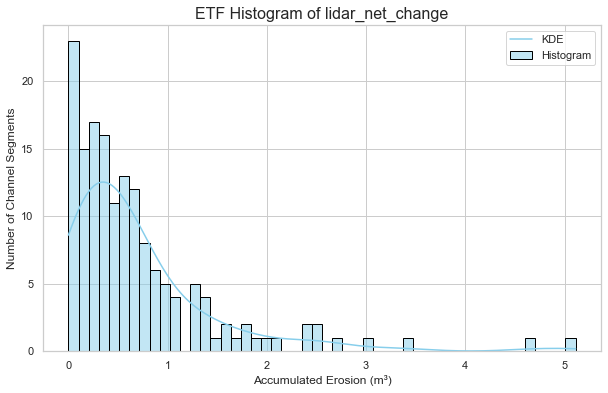

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import gamma
import os

# Parameters
watersheds = ["ETF"]  
input_folder = r"C:\Users\alextd\Documents\GitHub\ssn2-erosion-deposition-etf-cp\ETF\Inputs\Segmented 20m\Combined Watersheds"
save_folder = None
# save_folder = r"Y:\ATD\GIS\ETF\Plots\Histograms"
variable = 'lidar_net_change'
x_label = 'Accumulated Erosion (m³)'
plot_all = False

# Plot using Seaborn with Gamma distribution overlay
def plot_histogram_seaborn(gdf, column, bins=50, title=None, xlabel=None, ylabel='Frequency', kde=False, save_path = None):
    data = gdf[column].dropna()
    bin_width = (data.max() - data.min()) / bins
    
    # Fit Gamma distribution to the data
    try:
        shape, loc, scale = gamma.fit(data, floc=0)  # Fix location to 0 for better fit
        x = np.linspace(data.min(), data.max(), 1000)
        pdf_fitted = gamma.pdf(x, shape, loc, scale)
        pdf_scaled = pdf_fitted * len(data) * bin_width
        
    except Exception as e:
        print(f"Error fitting Gamma distribution: {e}")
        pdf_fitted = None
    
    
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    # Plot histogram
    sns_hist = sns.histplot(data, bins=bins, kde=kde, color='skyblue', edgecolor='black', label='Histogram')
    
    plt.title(title if title else f'Histogram of {column}', fontsize=16)
    plt.xlabel(xlabel if xlabel else column, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    # add KDE to legend
    if kde:
        sns_hist.legend(['KDE', 'Histogram',])
    plt.show()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)

# Create a single plot
plt.figure(figsize=(12, 6))

# Iterate over types and watersheds

for watershed in watersheds:
    # Determine the path for the watershed data
    gpkg_path = os.path.join(
        input_folder,
        f"{watershed} lidar net change ssn points.gpkg"
    )
    
    # Load the GeoPackage
    if not os.path.exists(gpkg_path):
        print(f"File not found: {gpkg_path}")
        continue

    # Read the GeoDataFrame
    gdf = gpd.read_file(gpkg_path)

    if variable not in gdf.columns:
        print(f"Column '{variable}' not found in the GeoDataFrame.")
        print(f"Available columns: {gdf.columns}")
        exit()

    else:
        
        if save_folder is not None:
            save_path = os.path.join(save_folder, f"{watershed}_{variable}_histogram.png")
        else:
            save_path = None
        plot_title = f'{watershed} Histogram of {variable}'
        
        plot_histogram_seaborn(
            gdf,
            column=variable,
            bins=50,
            xlabel=x_label,
            ylabel='Number of Channel Segments',
            kde=True,
            title=plot_title,
            save_path=save_path,
        )

        if plot_all:
            for column in gdf.columns:
                print(f"Processing column: {column}")
                # Check if column is numeric
                if pd.api.types.is_numeric_dtype(gdf[column]):
                    plot_histogram_seaborn(
                        gdf,
                        column=column,
                        bins=50,
                        xlabel=f'{column}',
                        ylabel='Number of Watersheds',
                        kde=True
                    )


In [19]:
import os
import shutil
import sys

# List of substrings that trigger deletion (case-insensitive)
DELETE_SUBSTRINGS = ["lidar net", "lidar deposition", "lidar_net", "lidar_deposition"]
# Substring to search for renaming (exact match, will replace all occurrences)
OLD_SUBSTR = "CP "
NEW_SUBSTR = "CPF "

def process_directory(root_folder):
    # Walk top-down so that we can modify the dirs list safely
    for current_root, dirs, files in os.walk(root_folder, topdown=True):
        # Process directories first
        for d in list(dirs):  # use a copy so we can modify dirs in-place
            d_path = os.path.join(current_root, d)
            d_lower = d.lower()
            # Check if this directory should be deleted based on any forbidden substring
            if any(sub in d_lower for sub in DELETE_SUBSTRINGS):
                print(f"Deleting directory: {d_path}")
                shutil.rmtree(d_path)
                dirs.remove(d)  # Remove from list so that os.walk doesn't traverse it
            else:
                # Check for renaming condition in the directory name
                if OLD_SUBSTR in d:
                    new_d = d.replace(OLD_SUBSTR, NEW_SUBSTR)
                    new_d_path = os.path.join(current_root, new_d)
                    print(f"Renaming directory: {d_path} -> {new_d_path}")
                    os.rename(d_path, new_d_path)
                    # Update the directory name in the dirs list so that os.walk continues correctly.
                    dirs[dirs.index(d)] = new_d

        # Process files in the current directory
        for f in files:
            f_path = os.path.join(current_root, f)
            f_lower = f.lower()
            # Delete files if their name contains any of the forbidden substrings
            if any(sub in f_lower for sub in DELETE_SUBSTRINGS):
                print(f"Deleting file: {f_path}")
                os.remove(f_path)
            else:
                # Rename files if they contain the old substring
                if OLD_SUBSTR in f:
                    new_f = f.replace(OLD_SUBSTR, NEW_SUBSTR)
                    new_f_path = os.path.join(current_root, new_f)
                    print(f"Renaming file: {f_path} -> {new_f_path}")
                    os.rename(f_path, new_f_path)


input_folder = r"C:\Users\alextd\Documents\GitHub\ssn2-erosion-deposition-etf-cp"
process_directory(input_folder)


Deleting file: C:\Users\alextd\Documents\GitHub\ssn2-erosion-deposition-etf-cp\CPF\Inputs\Segmented 20m\Individual Watersheds\MM lidar deposition ssn points.gpkg
Deleting file: C:\Users\alextd\Documents\GitHub\ssn2-erosion-deposition-etf-cp\CPF\Inputs\Segmented 20m\Individual Watersheds\MM lidar net change ssn points.gpkg
Deleting file: C:\Users\alextd\Documents\GitHub\ssn2-erosion-deposition-etf-cp\CPF\Inputs\Segmented 20m\Individual Watersheds\UE lidar deposition ssn points.gpkg
Deleting file: C:\Users\alextd\Documents\GitHub\ssn2-erosion-deposition-etf-cp\CPF\Inputs\Segmented 20m\Individual Watersheds\UE lidar net change ssn points.gpkg
Deleting file: C:\Users\alextd\Documents\GitHub\ssn2-erosion-deposition-etf-cp\CPF\Inputs\Segmented 20m\Individual Watersheds\UM lidar deposition ssn points.gpkg
Deleting file: C:\Users\alextd\Documents\GitHub\ssn2-erosion-deposition-etf-cp\CPF\Inputs\Segmented 20m\Individual Watersheds\UM lidar net change ssn points.gpkg
Deleting file: C:\Users\alex

In [ ]:
#!/usr/bin/env python3
import os
import argparse
import geopandas as gpd

def process_gpkg(gpkg_path):
    print(f"Processing: {gpkg_path}")
    try:
        # Read the GeoPackage into a GeoDataFrame
        gdf = gpd.read_file(gpkg_path)
    except Exception as e:
        print(f"Failed to read file {gpkg_path}: {e}")
        return
    
    # Check if the field exists and rename it if found
    if 'ch_flow_accumulation_max' in gdf.columns:
        gdf = gdf.rename(columns={'ch_flow_accumulation_max': 'ws_drainage_area'})
        try:
            # Delete the original file
            os.remove(gpkg_path)
            # Write the new GeoDataFrame to a GeoPackage with the same file name
            gdf.to_file(gpkg_path, driver="GPKG")
            print(f"Updated and saved: {gpkg_path}")
        except Exception as e:
            print(f"Error processing {gpkg_path}: {e}")
    else:
        print(f"Field 'ch_flow_accumulation_max' not found in {gpkg_path}. Skipping.")


input_folder = r"C:\Users\alextd\Documents\GitHub\ssn2-erosion-deposition-etf-cp\CPF\Inputs\Segmented 20m"
# Walk through all subdirectories in the input folder
for root, dirs, files in os.walk(input_folder):
    for file in files:
        if file.lower().endswith(".gpkg"):
            gpkg_path = os.path.join(root, file)
            process_gpkg(gpkg_path)

